**Imports and paths**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from scipy.stats import binomtest

PROJECT_ROOT = Path("/content/drive/MyDrive/Dissertation")

CLINICAL_DIR = PROJECT_ROOT / "05_Results" / "clinical_baselines"
IMAGE_DIR = PROJECT_ROOT / "05_Results" / "image_models"
MULTIMODAL_DIR = PROJECT_ROOT / "05_Results" / "multimodal"

SPLIT_DIR = (
    PROJECT_ROOT
    / "03_Data_Processed"
    / "splits"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "05_Results"
    / "statistical_analysis"
)

FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


**Load predictions**

In [2]:
clinical = pd.read_csv(
    CLINICAL_DIR / "clinical_test_predictions.csv"
)

image = pd.read_csv(
    IMAGE_DIR / "final_image_test_predictions.csv"
)

multimodal = pd.read_csv(
    MULTIMODAL_DIR / "final_multimodal_test_predictions.csv"
)

test_split = pd.read_csv(
    SPLIT_DIR / "test_breast_level.csv"
)

print("Clinical:", clinical.shape)
print("Image:", image.shape)
print("Multimodal:", multimodal.shape)
print("Test split:", test_split.shape)

Clinical: (317, 7)
Image: (317, 8)
Multimodal: (317, 8)
Test split: (317, 16)


**Standardise prediction columns**

In [3]:
clinical_clean = clinical[
    [
        "patient_breast_id",
        "target",
        "predicted_target",
        "malignant_probability"
    ]
].rename(
    columns={
        "predicted_target": "clinical_pred",
        "malignant_probability": "clinical_prob"
    }
)

image_clean = image[
    [
        "patient_breast_id",
        "target",
        "prediction",
        "malignant_probability"
    ]
].rename(
    columns={
        "target": "image_target",
        "prediction": "image_pred",
        "malignant_probability": "image_prob"
    }
)

multimodal_clean = multimodal[
    [
        "patient_breast_id",
        "target",
        "prediction",
        "malignant_probability"
    ]
].rename(
    columns={
        "target": "multimodal_target",
        "prediction": "multimodal_pred",
        "malignant_probability": "multimodal_prob"
    }
)

**Merge all three models**

In [4]:
master = (
    clinical_clean
    .merge(
        image_clean,
        on="patient_breast_id",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        multimodal_clean,
        on="patient_breast_id",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        test_split[
            [
                "patient_breast_id",
                "patient_id"
            ]
        ],
        on="patient_breast_id",
        how="left",
        validate="one_to_one"
    )
)

print("Aligned test breasts:", len(master))
print("Unique test patients:", master["patient_id"].nunique())

assert len(master) == 317

assert (
    master["target"]
    == master["image_target"]
).all()

assert (
    master["target"]
    == master["multimodal_target"]
).all()

print("Target agreement: PASSED")

Aligned test breasts: 317
Unique test patients: 205
Target agreement: PASSED


**Metric function**

In [5]:
def calculate_metrics(y_true, y_pred, y_prob):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "specificity": specificity,

        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),

        "pr_auc": average_precision_score(
            y_true,
            y_prob
        )
    }

**Point estimates**

In [6]:
MODEL_COLUMNS = {
    "Clinical-only": (
        "clinical_pred",
        "clinical_prob"
    ),

    "Image-only": (
        "image_pred",
        "image_prob"
    ),

    "Multimodal Fusion": (
        "multimodal_pred",
        "multimodal_prob"
    )
}

point_results = []

for model_name, (pred_col, prob_col) in MODEL_COLUMNS.items():

    metrics = calculate_metrics(
        master["target"],
        master[pred_col],
        master[prob_col]
    )

    point_results.append({
        "model": model_name,
        **metrics
    })

point_df = pd.DataFrame(point_results)

display(point_df.round(4))

,model,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,Clinical-only,0.9306,0.9194,0.9607,0.8921,0.9396,0.9814,0.9836
1,Image-only,0.7413,0.8243,0.6854,0.8129,0.7485,0.8284,0.8628
2,Multimodal Fusion,0.7981,0.8519,0.7753,0.8273,0.8118,0.8717,0.8914


**Patient-cluster bootstrap**

In [7]:
N_BOOTSTRAPS = 2000
RANDOM_STATE = 42

rng = np.random.default_rng(
    RANDOM_STATE
)

unique_patients = (
    master["patient_id"]
    .unique()
)

bootstrap_records = []

for iteration in range(N_BOOTSTRAPS):

    sampled_patients = rng.choice(
        unique_patients,
        size=len(unique_patients),
        replace=True
    )

    sampled_parts = []

    for new_cluster_id, patient_id in enumerate(
        sampled_patients
    ):

        patient_rows = master[
            master["patient_id"] == patient_id
        ].copy()

        # Allows the same patient to appear multiple times
        patient_rows[
            "_bootstrap_cluster"
        ] = new_cluster_id

        sampled_parts.append(
            patient_rows
        )

    sample = pd.concat(
        sampled_parts,
        ignore_index=True
    )

    # Occasionally a bootstrap sample could contain only
    # one class. Skip it because ROC-AUC is undefined.
    if sample["target"].nunique() < 2:
        continue

    for model_name, (
        pred_col,
        prob_col
    ) in MODEL_COLUMNS.items():

        metrics = calculate_metrics(
            sample["target"],
            sample[pred_col],
            sample[prob_col]
        )

        bootstrap_records.append({
            "bootstrap": iteration,
            "model": model_name,
            **metrics
        })

bootstrap_df = pd.DataFrame(
    bootstrap_records
)

print("Bootstrap result rows:", len(bootstrap_df))

Bootstrap result rows: 6000


**Calculate 95% confidence intervals**

In [8]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "roc_auc",
    "pr_auc"
]

ci_records = []

for _, row in point_df.iterrows():

    model_name = row["model"]

    boot_model = bootstrap_df[
        bootstrap_df["model"] == model_name
    ]

    for metric in metrics:

        lower = np.percentile(
            boot_model[metric],
            2.5
        )

        upper = np.percentile(
            boot_model[metric],
            97.5
        )

        ci_records.append({
            "model": model_name,
            "metric": metric,
            "estimate": row[metric],
            "ci_lower": lower,
            "ci_upper": upper
        })

ci_df = pd.DataFrame(
    ci_records
)

ci_df.to_csv(
    OUTPUT_DIR / "model_metric_95ci.csv",
    index=False
)

display(
    ci_df.round(4)
)

,model,metric,estimate,ci_lower,ci_upper
0,Clinical-only,accuracy,0.9306,0.9000,0.9572
1,Clinical-only,precision,0.9194,0.8789,0.9575
2,Clinical-only,recall,0.9607,0.9286,0.9842
3,Clinical-only,specificity,0.8921,0.8366,0.9441
4,Clinical-only,f1,0.9396,0.9126,0.9630
5,Clinical-only,roc_auc,0.9814,0.9669,0.9924
6,Clinical-only,pr_auc,0.9836,0.9696,0.9938
7,Image-only,accuracy,0.7413,0.6859,0.7914
8,Image-only,precision,0.8243,0.7616,0.8816
9,Image-only,recall,0.6854,0.6162,0.7486


**Report-friendly CI table**

In [9]:
report_ci = ci_df.copy()

report_ci["estimate_95ci"] = (
    report_ci.apply(
        lambda row:
        f"{row['estimate']:.3f} "
        f"({row['ci_lower']:.3f}–{row['ci_upper']:.3f})",
        axis=1
    )
)

report_table = report_ci.pivot(
    index="model",
    columns="metric",
    values="estimate_95ci"
)

report_table.to_csv(
    OUTPUT_DIR / "report_ready_model_ci_table.csv"
)

display(report_table)

metric,accuracy,f1,pr_auc,precision,recall,roc_auc,specificity
model,,,,,,,
Clinical-only,0.931 (0.900–0.957),0.940 (0.913–0.963),0.984 (0.970–0.994),0.919 (0.879–0.957),0.961 (0.929–0.984),0.981 (0.967–0.992),0.892 (0.837–0.944)
Image-only,0.741 (0.686–0.791),0.748 (0.690–0.800),0.863 (0.815–0.906),0.824 (0.762–0.882),0.685 (0.616–0.749),0.828 (0.780–0.872),0.813 (0.743–0.878)
Multimodal Fusion,0.798 (0.753–0.842),0.812 (0.764–0.855),0.891 (0.847–0.930),0.852 (0.798–0.903),0.775 (0.715–0.834),0.872 (0.830–0.910),0.827 (0.759–0.889)


**Paired bootstrap differences**

In [10]:
comparisons = [
    (
        "Multimodal Fusion",
        "Image-only"
    ),
    (
        "Clinical-only",
        "Multimodal Fusion"
    ),
    (
        "Clinical-only",
        "Image-only"
    )
]

difference_records = []

for model_a, model_b in comparisons:

    a = bootstrap_df[
        bootstrap_df["model"] == model_a
    ].set_index("bootstrap")

    b = bootstrap_df[
        bootstrap_df["model"] == model_b
    ].set_index("bootstrap")

    shared_bootstraps = (
        a.index
        .intersection(b.index)
    )

    for metric in metrics:

        differences = (
            a.loc[
                shared_bootstraps,
                metric
            ]
            -
            b.loc[
                shared_bootstraps,
                metric
            ]
        )

        difference_records.append({
            "comparison":
                f"{model_a} - {model_b}",

            "metric":
                metric,

            "mean_difference":
                differences.mean(),

            "ci_lower":
                np.percentile(
                    differences,
                    2.5
                ),

            "ci_upper":
                np.percentile(
                    differences,
                    97.5
                )
        })

difference_df = pd.DataFrame(
    difference_records
)

difference_df.to_csv(
    OUTPUT_DIR
    / "paired_bootstrap_model_differences.csv",
    index=False
)

display(
    difference_df.round(4)
)

,comparison,metric,mean_difference,ci_lower,ci_upper
0,Multimodal Fusion - Image-only,accuracy,0.0569,0.0288,0.0881
1,Multimodal Fusion - Image-only,precision,0.0279,-0.0010,0.0592
2,Multimodal Fusion - Image-only,recall,0.0898,0.0508,0.1333
3,Multimodal Fusion - Image-only,specificity,0.0148,-0.0173,0.0511
4,Multimodal Fusion - Image-only,f1,0.0634,0.0352,0.0973
5,Multimodal Fusion - Image-only,roc_auc,0.0433,0.0323,0.0557
6,Multimodal Fusion - Image-only,pr_auc,0.0284,0.0197,0.0386
7,Clinical-only - Multimodal Fusion,accuracy,0.1323,0.0833,0.1827
8,Clinical-only - Multimodal Fusion,precision,0.0673,0.0182,0.1167
9,Clinical-only - Multimodal Fusion,recall,0.1853,0.1202,0.2541


**McNemar exact test**

In [11]:
def exact_mcnemar(
    dataframe,
    pred_a,
    pred_b,
    model_a,
    model_b
):

    truth = dataframe["target"]

    a_correct = (
        dataframe[pred_a] == truth
    )

    b_correct = (
        dataframe[pred_b] == truth
    )

    # A correct, B wrong
    b_count = (
        a_correct
        & ~b_correct
    ).sum()

    # A wrong, B correct
    c_count = (
        ~a_correct
        & b_correct
    ).sum()

    discordant = (
        b_count + c_count
    )

    if discordant == 0:

        p_value = 1.0

    else:

        p_value = binomtest(
            min(b_count, c_count),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue

    return {
        "comparison":
            f"{model_a} vs {model_b}",

        "A_correct_B_wrong":
            int(b_count),

        "A_wrong_B_correct":
            int(c_count),

        "discordant_pairs":
            int(discordant),

        "exact_p_value":
            p_value
    }


mcnemar_results = pd.DataFrame([
    exact_mcnemar(
        master,
        "multimodal_pred",
        "image_pred",
        "Multimodal Fusion",
        "Image-only"
    ),

    exact_mcnemar(
        master,
        "clinical_pred",
        "multimodal_pred",
        "Clinical-only",
        "Multimodal Fusion"
    ),

    exact_mcnemar(
        master,
        "clinical_pred",
        "image_pred",
        "Clinical-only",
        "Image-only"
    )
])

mcnemar_results.to_csv(
    OUTPUT_DIR
    / "mcnemar_exact_model_comparison.csv",
    index=False
)

display(mcnemar_results)

,comparison,A_correct_B_wrong,A_wrong_B_correct,discordant_pairs,exact_p_value
0,Multimodal Fusion vs Image-only,20,2,22,1.211166e-04
1,Clinical-only vs Multimodal Fusion,53,11,64,1.005858e-07
2,Clinical-only vs Image-only,72,12,84,1.393229e-11


**ROC-AUC confidence interval figure**

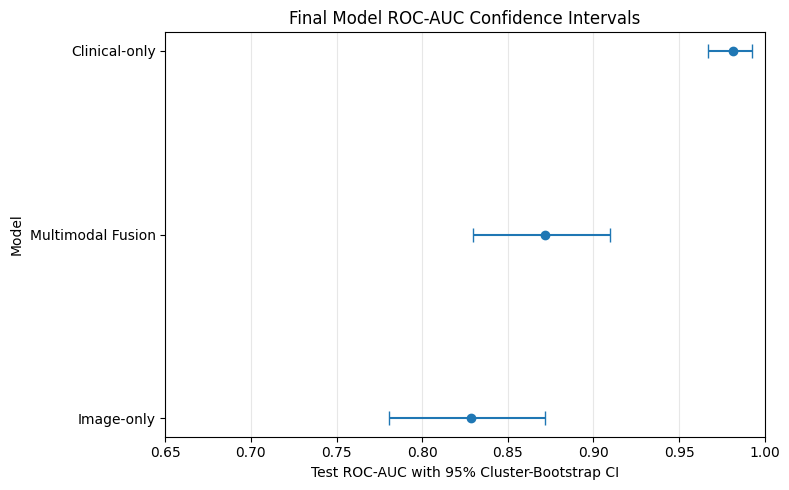

In [12]:
roc_ci = ci_df[
    ci_df["metric"] == "roc_auc"
].copy()

roc_ci = roc_ci.sort_values(
    "estimate"
)

errors = np.vstack([
    roc_ci["estimate"]
    - roc_ci["ci_lower"],

    roc_ci["ci_upper"]
    - roc_ci["estimate"]
])

plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    roc_ci["estimate"],
    roc_ci["model"],
    xerr=errors,
    fmt="o",
    capsize=5
)

plt.xlabel(
    "Test ROC-AUC with 95% Cluster-Bootstrap CI"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Final Model ROC-AUC Confidence Intervals"
)

plt.xlim(
    0.65,
    1.0
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "01_roc_auc_95ci_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Save final consolidated results**

In [13]:
master.to_csv(
    OUTPUT_DIR
    / "aligned_final_test_predictions.csv",
    index=False
)

point_df.to_csv(
    OUTPUT_DIR
    / "final_point_estimate_metrics.csv",
    index=False
)

bootstrap_df.to_csv(
    OUTPUT_DIR
    / "cluster_bootstrap_results.csv",
    index=False
)

print("=" * 70)
print("FINAL STATISTICAL ANALYSIS COMPLETE")
print("=" * 70)

print("\nSaved:")
print("- final_point_estimate_metrics.csv")
print("- model_metric_95ci.csv")
print("- report_ready_model_ci_table.csv")
print("- paired_bootstrap_model_differences.csv")
print("- mcnemar_exact_model_comparison.csv")
print("- aligned_final_test_predictions.csv")
print("- cluster_bootstrap_results.csv")
print("- 01_roc_auc_95ci_comparison.png")

FINAL STATISTICAL ANALYSIS COMPLETE

Saved:
- final_point_estimate_metrics.csv
- model_metric_95ci.csv
- report_ready_model_ci_table.csv
- paired_bootstrap_model_differences.csv
- mcnemar_exact_model_comparison.csv
- aligned_final_test_predictions.csv
- cluster_bootstrap_results.csv
- 01_roc_auc_95ci_comparison.png
